## ML Classical Baselines

In [1]:
import importlib
from pathlib import Path

from IPython.display import display

import utils.ml_pipeline as ml_pipeline
import utils.plots as ml_plots

importlib.reload(ml_pipeline)
importlib.reload(ml_plots)

from utils.cache import get_cache_path, get_results_path
from utils.ml_pipeline import (
    best_confusion_predictions,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_or_build_none_reference_features,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    plot_block_vs_lovo_position_accuracy,
    plot_lovo_fold_spread,
    print_normalization_discriminability,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "data"
CALIBRATION_MODE = "rssi"   # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "packet_minmax",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_user"  # per_user | global (empty_baseline only)

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "require_all_esps": False,
}

# MODELS_TO_RUN = ("RF", "KNN", "SVM")
MODELS_TO_RUN = ("RF", )
BANDS_TO_RUN = ("2.4 GHz", "5 GHz", "Fusion")
SPLIT_MODES = ("block", "lovo")      # "random" remains available for contamination demonstrations.
RUN_GRID_SEARCH = False
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
SVM_KERNEL = "rbf"            # "rbf" | "linear"
N_JOBS = -1

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
if preproc_opts.get("normalization") == "empty_baseline":
    preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path(preproc_opts, feat_opts)
print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
summary_dir = results_dir / "summary"
tables_dir = results_dir / "tables"
tuning_dir = results_dir / "tuning"
plots_dir = results_dir / "plots"
for directory in (summary_dir, tables_dir, tuning_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

Feature cache path: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-packet_minmax\feat=win60-step30
Results path: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30


## Raw Data

In [3]:
magnitude_data, csv_diagnostics = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
)

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19


#### Feature Dataframes

In [4]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)

none_reference_dataframes = (
    feature_dataframes
    if preproc_opts.get("normalization") == "none"
    else load_or_build_none_reference_features(
        magnitude_data,
        active_preproc_opts=preproc_opts,
        feat_opts=feat_opts,
    )
)
fisher_diagnostics = print_normalization_discriminability(
    feature_dataframes,
    normalization=preproc_opts.get("normalization", "none"),
    reference_feature_dataframes=none_reference_dataframes,
    bands_to_run=BANDS_TO_RUN,
)
display(fisher_diagnostics)
del magnitude_data


[cache miss] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-packet_minmax\feat=win60-step30, computing...
2.4 GHz: 17710 windows, 2708 columns
5 GHz: 19302 windows, 3368 columns
Fusion: 17670 windows, 6068 columns
[normalization diagnostic] none reference cache: c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-none\feat=win60-step30
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-none\feat=win60-step30\2_4ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-none\feat=win60-step30\5ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=norm-none\feat=win60-step30\fusion.parquet
[no

,dataset,normalization,median_fisher_ratio,none_median_fisher_ratio
0,2.4 GHz,packet_minmax,0.048276,0.050891
1,5 GHz,packet_minmax,0.046627,0.028059
2,Fusion,packet_minmax,0.048920,0.035583


#### Model Parameters

In [5]:
TUNED_SUMMARY_PATH = tuning_dir / "tuned_summary.csv"
GRID_LOG_PATH = tuning_dir / "full_grid_log.csv"

params_lookup = load_params_lookup(
    TUNED_SUMMARY_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
)
for key, value in params_lookup.items():
    print(f"{key}: {value}")

('RF', '2.4 GHz'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', '5 GHz'): {'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', 'Fusion'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}


##### Optional Grid Search

In [6]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    tuned_summary_path=TUNED_SUMMARY_PATH,
    grid_log_path=GRID_LOG_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [7]:
global_summary, global_predictions_by_key = run_global_baselines(
    feature_dataframes,
    params_lookup=params_lookup,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    results_dir=results_dir,
    summary_dir=summary_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    force_retrain=FORCE_RETRAIN,
    save_predictions=SAVE_PREDICTIONS,
    svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
display(global_summary)

[predictions] Saved c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30\predictions\2_4ghz__rf__block.parquet
[baseline] 2.4 GHz / RF / block: majority_position_accuracy=0.0223, majority_room_accuracy=0.6541
[LOVO check] 2.4 GHz: every observed position has at least two users.
[LOVO check] 2.4 GHz: held_out_user=01 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=02 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=03 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=04 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=05 training covers 52/52 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=06 training co

,dataset,model,split,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,position_accuracy,macro_f1,...,majority_position_accuracy_std,majority_position_accuracy_min,majority_position_accuracy_max,majority_room_accuracy_mean,majority_room_accuracy_std,majority_room_accuracy_min,majority_room_accuracy_max,n_folds,n_test_windows,position_accuracy_pooled
0,2.4 GHz,RF,block,500,log2,None,2,1,0.885445,0.885157,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.4 GHz,RF,lovo,500,log2,None,2,1,NaN,NaN,...,0.001329,0.018701,0.022508,0.653166,0.013275,0.630940,0.672266,6.0,17710.0,0.168436
2,5 GHz,RF,block,500,sqrt,None,2,1,0.871318,0.870627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5 GHz,RF,lovo,500,sqrt,None,2,1,NaN,NaN,...,0.000397,0.019114,0.020151,0.656967,0.006107,0.651763,0.668993,6.0,19302.0,0.101907
4,Fusion,RF,block,500,log2,None,2,1,0.946309,0.946046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fusion,RF,lovo,500,log2,None,2,1,NaN,NaN,...,0.001333,0.018701,0.022548,0.653864,0.013400,0.631353,0.672266,6.0,17670.0,0.154612


#### Analysis Tables

In [8]:
all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=summary_dir / "global_summary.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

display(master_table)
display(per_room_table)

[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30\predictions\2_4ghz__rf__block.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30\predictions\2_4ghz__rf__lovo.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30\predictions\5ghz__rf__block.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30\predictions\5ghz__rf__lovo.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=norm-packet_minmax\feat=win60-step30\predictions\fu

,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,...,rmse_distance_error_std,p90_distance_error_mean,p90_distance_error_std,position_accuracy_pooled,majority_position_accuracy,majority_room_accuracy,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,RF,2.4 GHz,block,0.885445,0.885157,0.993801,0.251443,0.0,0.947022,1.0,...,NaN,NaN,NaN,NaN,0.022316,0.654104,58.164021,0.487118,58.803621,RandomForestClassifier
1,RF,2.4 GHz,lovo,0.1643 +/- 0.1336,0.1444 +/- 0.1312,0.6435 +/- 0.0833,4.0689 +/- 0.4768,3.4148 +/- 1.0986,5.1715 +/- 0.3160,8.9876 +/- 1.5056,...,0.316015,8.987636,1.505615,0.168436,0.020057,0.653166,460.209823,1.969727,466.252961,RandomForestClassifier
2,RF,5 GHz,block,0.871318,0.870627,0.994684,0.26276,0.0,0.894675,1.0,...,NaN,NaN,NaN,NaN,0.022591,0.658472,301.857429,0.437709,302.452782,RandomForestClassifier
3,RF,5 GHz,lovo,0.1017 +/- 0.0785,0.0824 +/- 0.0777,0.6290 +/- 0.1070,3.8522 +/- 0.4937,3.4678 +/- 0.7544,4.7723 +/- 0.4931,8.2538 +/- 1.3885,...,0.493057,8.253797,1.388542,0.101907,0.019482,0.656967,2723.745515,3.630991,2735.623699,RandomForestClassifier
4,RF,Fusion,block,0.946309,0.946046,0.998509,0.087248,0.0,0.457489,0.0,...,NaN,NaN,NaN,NaN,0.022371,0.655481,69.796309,0.562017,70.508010,RandomForestClassifier
5,RF,Fusion,lovo,0.1511 +/- 0.1240,0.1206 +/- 0.1222,0.6261 +/- 0.0906,3.8060 +/- 0.5534,3.1484 +/- 1.1425,4.8594 +/- 0.5141,8.7021 +/- 1.7282,...,0.514139,8.702139,1.728195,0.154612,0.019943,0.653864,483.966316,2.092094,490.001031,RandomForestClassifier


,model,dataset,split,true_room,samples,position_accuracy
0,RF,2.4 GHz,block,1,2638,0.876801
1,RF,2.4 GHz,block,2,768,0.880208
2,RF,2.4 GHz,block,3,627,0.928230
3,RF,2.4 GHz,lovo,1,11564,0.173469
4,RF,2.4 GHz,lovo,2,3373,0.181441
5,RF,2.4 GHz,lovo,3,2773,0.131626
6,RF,5 GHz,block,1,2973,0.865792
7,RF,5 GHz,block,2,862,0.896752
8,RF,5 GHz,block,3,680,0.863235
9,RF,5 GHz,lovo,1,12682,0.111260


#### LOVO cross-user analysis


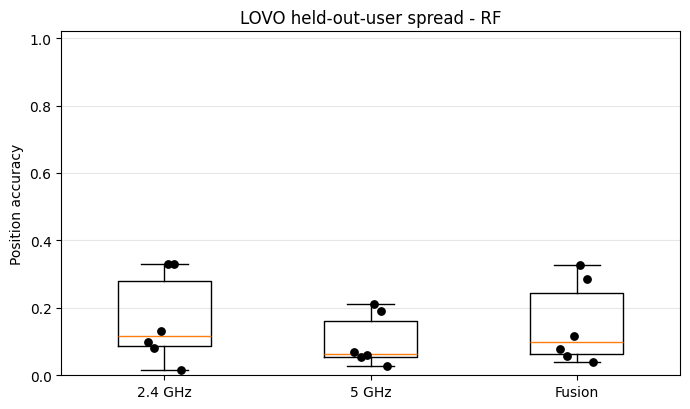

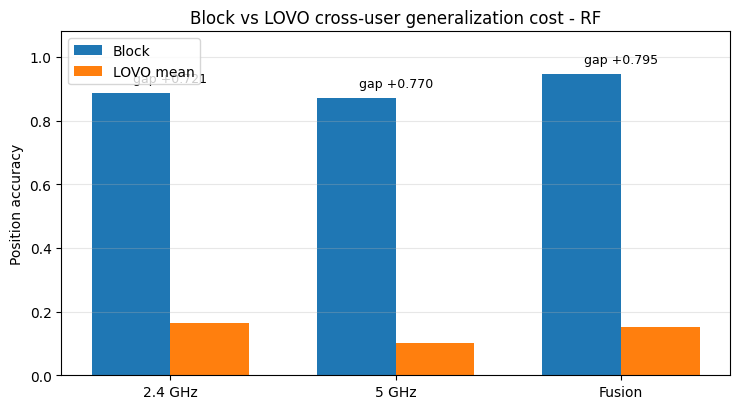

,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,RF,2.4 GHz,0.1643 +/- 0.1336,0.1444 +/- 0.1312,0.6435 +/- 0.0833,4.0689 +/- 0.4768,3.4148 +/- 1.0986,5.1715 +/- 0.3160,8.9876 +/- 1.5056,0.0201 +/- 0.0013,0.6532 +/- 0.0133
1,RF,5 GHz,0.1017 +/- 0.0785,0.0824 +/- 0.0777,0.6290 +/- 0.1070,3.8522 +/- 0.4937,3.4678 +/- 0.7544,4.7723 +/- 0.4931,8.2538 +/- 1.3885,0.0195 +/- 0.0004,0.6570 +/- 0.0061
2,RF,Fusion,0.1511 +/- 0.1240,0.1206 +/- 0.1222,0.6261 +/- 0.0906,3.8060 +/- 0.5534,3.1484 +/- 1.1425,4.8594 +/- 0.5141,8.7021 +/- 1.7282,0.0199 +/- 0.0013,0.6539 +/- 0.0134


,model,dataset,held_out_user,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,samples,majority_position_accuracy,majority_room_accuracy,n_test_windows,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,RF,2.4 GHz,1,0.099496,0.085557,0.666247,4.319315,4.123106,5.101983,8.062258,3176.0,0.020466,0.655227,3176,75.612320,0.390907,76.109872,RandomForestClassifier
1,RF,2.4 GHz,2,0.080743,0.064134,0.661665,3.989333,4.000000,4.629426,7.071068,2799.0,0.022508,0.630940,2799,83.585697,0.320800,83.975765,RandomForestClassifier
2,RF,2.4 GHz,3,0.131612,0.099261,0.479286,4.514327,4.123106,5.541805,9.486833,3138.0,0.019758,0.650733,3138,82.530923,0.498740,83.194703,RandomForestClassifier
3,RF,2.4 GHz,4,0.330103,0.312889,0.718023,3.534478,2.000000,5.339689,10.198039,3096.0,0.019380,0.656654,3096,72.562527,0.281153,72.913595,RandomForestClassifier
4,RF,2.4 GHz,5,0.329140,0.303137,0.676641,3.489374,2.000000,5.335720,11.045361,2941.0,0.018701,0.653179,2941,71.202744,0.269410,71.537532,RandomForestClassifier
5,RF,2.4 GHz,6,0.014844,0.001198,0.659375,4.566802,4.242641,5.080562,8.062258,2560.0,0.019531,0.672266,2560,74.715613,0.208717,74.978171,RandomForestClassifier
6,RF,5 GHz,1,0.067658,0.043533,0.587379,4.206925,4.123106,5.002063,8.154234,3296.0,0.019114,0.668993,3296,439.936184,0.712660,440.899958,RandomForestClassifier
7,RF,5 GHz,2,0.052897,0.037814,0.630982,3.473235,3.162278,4.030074,6.324555,3176.0,0.020151,0.651763,3176,449.117174,0.541455,449.810401,RandomForestClassifier
8,RF,5 GHz,3,0.061346,0.047273,0.448826,4.451531,4.123106,5.401617,8.944272,3195.0,0.019405,0.655399,3195,446.205911,0.353909,446.658107,RandomForestClassifier
9,RF,5 GHz,4,0.211598,0.188846,0.767736,3.112478,2.236068,4.597461,9.049847,3242.0,0.019741,0.655768,3242,515.257105,0.666694,516.141178,RandomForestClassifier


In [9]:
if "lovo" in SPLIT_MODES:
    lovo_per_fold, lovo_summary = load_lovo_summary_tables(summary_dir)
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)
    save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('lovo rf fold spread')}.pdf",
    )
    plot_block_vs_lovo_position_accuracy(
        globals().get("global_summary", master_table),
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('block vs lovo rf position accuracy')}.pdf",
    )

    display(lovo_table)
    display(lovo_per_fold.loc[lovo_per_fold["model"] == "RF"])
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")

#### Analysis Figures

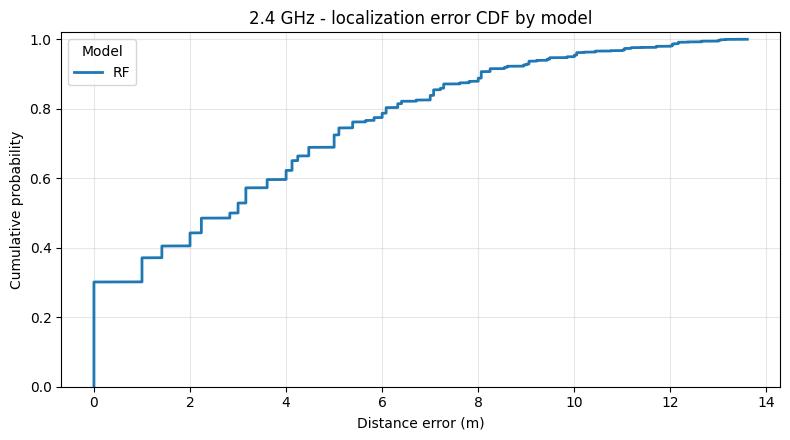

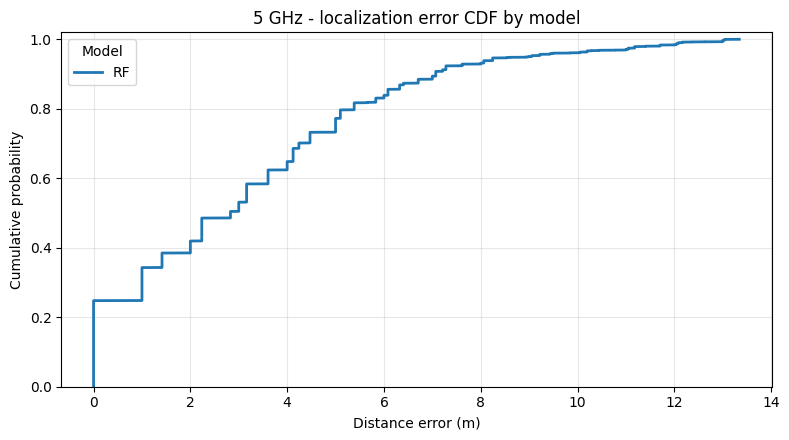

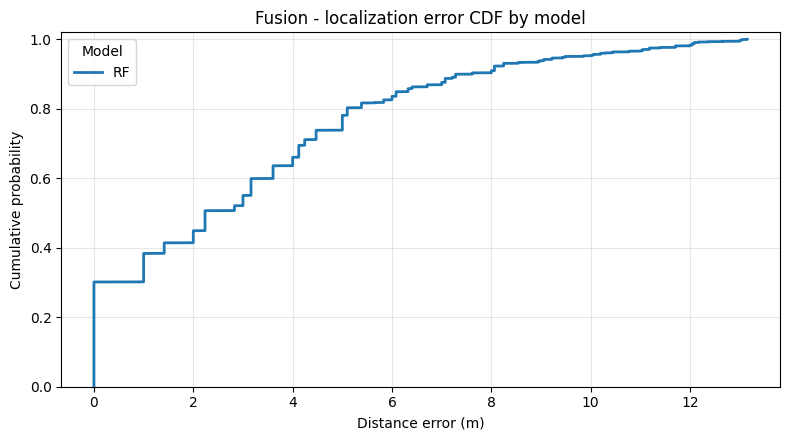

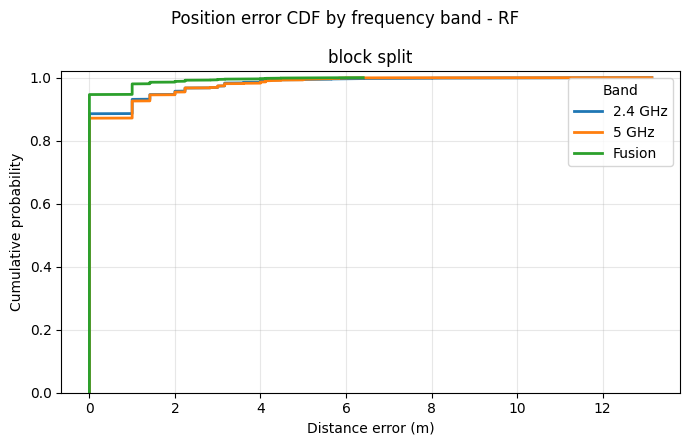

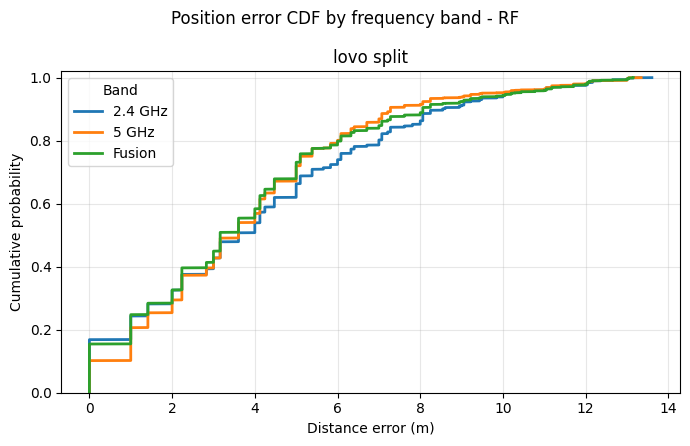

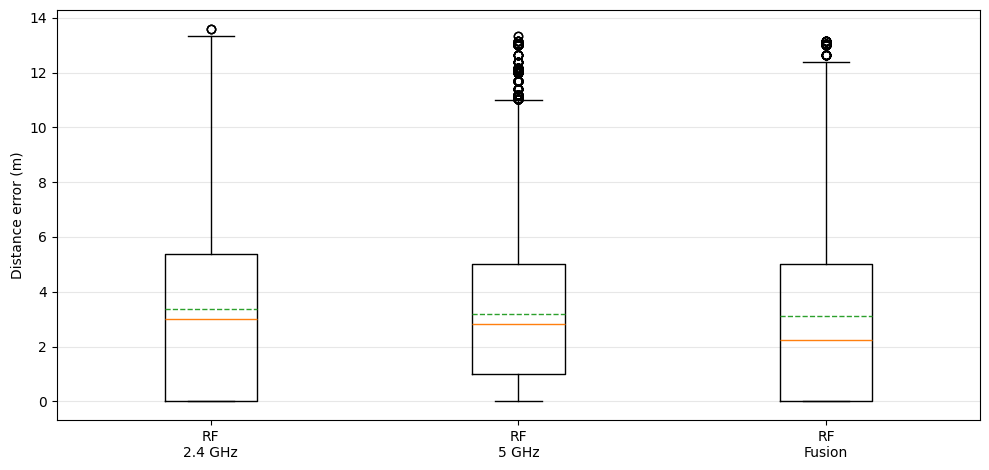

In [10]:
if SHOW_CDF_BY_BAND:
    for band in BANDS_TO_RUN:
        plot_localization_error_cdf_by_model(
            all_global_predictions,
            dataset=band,
            save_path=plots_dir / f"cdf_by_model_{_slugify(band)}.pdf",
        )

if SHOW_CDF_BY_MODEL:
    for model in MODELS_TO_RUN:
        model_predictions = all_global_predictions.loc[all_global_predictions["model"] == model]
        plot_band_error_cdf(
            model_predictions,
            model_label=model,
            split_modes=SPLIT_MODES,
            band_order=BANDS_TO_RUN,
            save_path=plots_dir,
        )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_global_predictions,
        models=MODELS_TO_RUN,
        bands=BANDS_TO_RUN,
        save_path=plots_dir / "boxplot_model_band_distance_error.pdf",
    )

#### Confusion Matrix And Floor Plan

In [11]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_global_predictions,
    master_table,
    dataset=CONFUSION_DATASET,
    model=CONFUSION_MODEL,
)
print(f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET}")

if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=f"{CONFUSION_DATASET} / {confusion_model} localization heatmap",
        save_path=plots_dir / f"floor_plan_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.pdf",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=plots_dir / f"confusion_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.pdf",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = plots_dir / f"confusion_by_room_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )

TypeError: '<' not supported between instances of 'float' and 'str'